# Ruggedness landscape features

Illustrates MOLA's **ruggedness** landscape features (paper §4.1.4, Table 1). Each of the thirteen evolvability measures gets a ruggedness sibling: the Spearman correlation of that same per-solution measure over every directed neighbour edge — "the larger the correlation, the smoother the landscape." One generic procedure (`mola.ruggedness.neighbour_correlation`), applied uniformly, not thirteen bespoke implementations.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook: `dist_x_cor_neig`, `dist_f_cor_neig`.

## `dist_x_cor_neig`, `dist_f_cor_neig` — ruggedness of the neighbour-distance measures

> "for each of the thirteen measures, we compute the (Spearman) correlation coefficient over each pair of neighbours in the sample" (§4.1.4)

The measure here is each solution's *own* average distance to *its* neighbours (`dist_x_avg_neig`/`dist_f_avg_neig`'s per-solution array, before the final sample-wide mean) — correlated between neighbouring solutions. A high correlation means neighbouring solutions tend to have similarly-sized neighbourhoods (smooth); a low or negative one means a solution's local distance scale says little about its neighbour's (rugged).

Structurally immune to a `||`-vs-`&&` length-guard bug MOORPHOLOGY has for these same two features: the two correlated arrays here come from one shared edge loop and cannot disagree in length by construction, so no length check is needed at all.

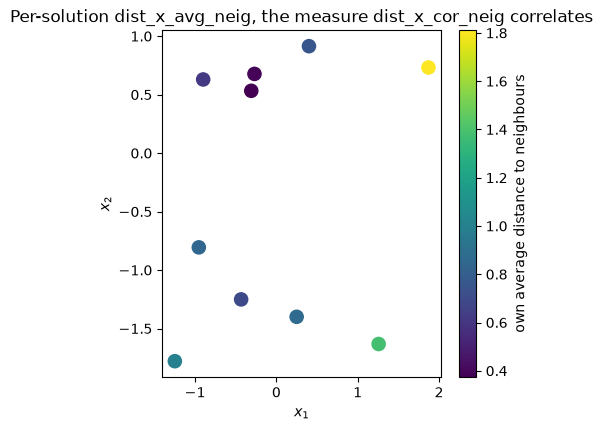

dist_x_cor_neig = 0.450
dist_f_cor_neig = -0.099


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import build_neighbourhood, neighbour_distances
from mola.features import dist_f_cor_neig, dist_x_cor_neig

# Same toy bi-objective problem as the evolvability notebook: two spheres centred at
# (1, 1) and (-1, -1).
rug_rng = np.random.default_rng(seed=2)
variables = rug_rng.uniform(low=-2.0, high=2.0, size=(10, 2))
objectives = np.column_stack(
    [
        ((variables - 1.0) ** 2).sum(axis=1),
        ((variables + 1.0) ** 2).sum(axis=1),
    ]
)
neighbourhood = build_neighbourhood(variables, neighbours=variables.shape[1])

dist_x_measure = neighbour_distances(variables, neighbourhood).mean(axis=1)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
scatter = ax.scatter(variables[:, 0], variables[:, 1], c=dist_x_measure, cmap="viridis", s=90)
fig.colorbar(scatter, ax=ax, label="own average distance to neighbours")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Per-solution dist_x_avg_neig, the measure dist_x_cor_neig correlates")
plt.show()

print(f"dist_x_cor_neig = {dist_x_cor_neig(variables, neighbourhood):.3f}")
print(f"dist_f_cor_neig = {dist_f_cor_neig(objectives, neighbourhood):.3f}")

## `sup_cor_neig`, `inf_cor_neig`, `inc_cor_neig` — ruggedness of the dominance proportions

Correlates each solution's own dominating/dominated/incomparable neighbour proportion (`mola.features.evolvability.sup_avg_neig` and siblings' per-solution measure) with its neighbours', over the same toy sample and `neighbourhood` as the section above.

In [2]:
from mola.dominance import neighbourhood_dominance
from mola.features import inc_cor_neig, inf_cor_neig, sup_cor_neig

dominance = neighbourhood_dominance(objectives, neighbourhood)

print(f"sup_cor_neig = {sup_cor_neig(dominance, neighbourhood):.3f}")
print(f"inf_cor_neig = {inf_cor_neig(dominance, neighbourhood):.3f}")
print(f"inc_cor_neig = {inc_cor_neig(dominance, neighbourhood):.3f}")

sup_cor_neig = -0.067
inf_cor_neig = -0.247
inc_cor_neig = 0.823


## `dist_f_dist_x_cor_neig`, `diff_f_cor_neig`, `diff_f_dist_x_cor_neig`

The two `*_dist_x_cor_neig` features compute their ratio **per solution first**, then correlate — unlike their evolvability namesakes (`dist_f_dist_x_avg_neig`, `diff_f_dist_x_avg_neig`), which ratio two already sample-wide-averaged scalars.
`diff_f_cor_neig` correlates the mean-absolute-objective-difference measure (`diff_f_avg_neig`'s per-solution array).

In [3]:
from mola.features import diff_f_cor_neig, diff_f_dist_x_cor_neig, dist_f_dist_x_cor_neig

print(
    f"dist_f_dist_x_cor_neig = {dist_f_dist_x_cor_neig(objectives, variables, neighbourhood):.3f}"
)
print(f"diff_f_cor_neig        = {diff_f_cor_neig(objectives, neighbourhood):.3f}")
print(
    f"diff_f_dist_x_cor_neig = {diff_f_dist_x_cor_neig(objectives, variables, neighbourhood):.3f}"
)

dist_f_dist_x_cor_neig = 0.125
diff_f_cor_neig        = -0.090
diff_f_dist_x_cor_neig = 0.081


## `hv_cor_neig`, `hvd_cor_neig` — ruggedness of the hypervolume measures

Correlates each solution's own singleton hypervolume (`hv_avg_neig`'s per-solution measure) and its average hypervolume difference with neighbours (`hvd_avg_neig`'s), against the same shared reference point used throughout.

In [4]:
from mola.features import hv_cor_neig, hvd_cor_neig
from mola.hypervolume import reference_point

ref = reference_point(objectives)

print(f"hv_cor_neig  = {hv_cor_neig(objectives, ref, neighbourhood):.3f}")
print(f"hvd_cor_neig = {hvd_cor_neig(objectives, neighbourhood, ref):.3f}")

hv_cor_neig  = 0.478
hvd_cor_neig = -0.136
